In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
X,y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [8]:
df = pd.DataFrame({'feature1':X[:,0], 'feature2':X[:,1], 'target':y})

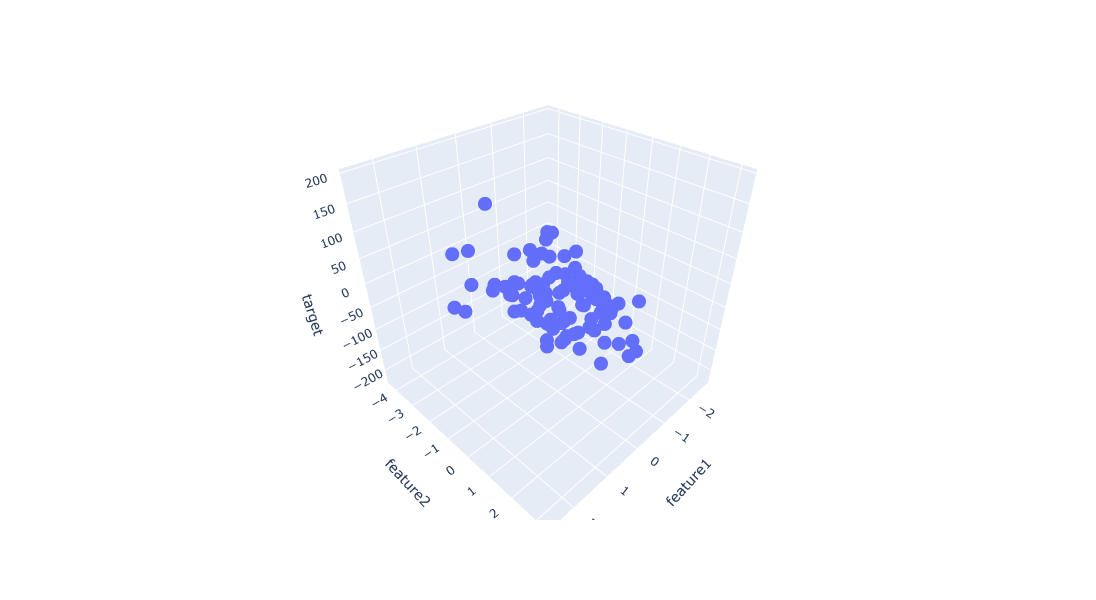

In [16]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.update_layout(width=1000, height=600)
fig.show()

In [20]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df.iloc[:,-1],test_size=0.2,random_state=42)

In [24]:
lr = LinearRegression()

In [25]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = lr.predict(X_test)

In [27]:
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print('R2 score: ', r2_score(y_test,y_pred))

MAE:  29.95890497484773
MSE:  1268.0290551463404
R2 score:  0.7379318799134476


In [54]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(x, x)

In [42]:
xGrid.ravel().shape

(100,)

In [55]:
final = np.hstack((xGrid.ravel().reshape(100,1),yGrid.ravel().reshape(100,1)))

In [56]:
z = lr.predict(pd.DataFrame(final, columns=['feature1','feature2']))

In [57]:
z = z.reshape(10,10)

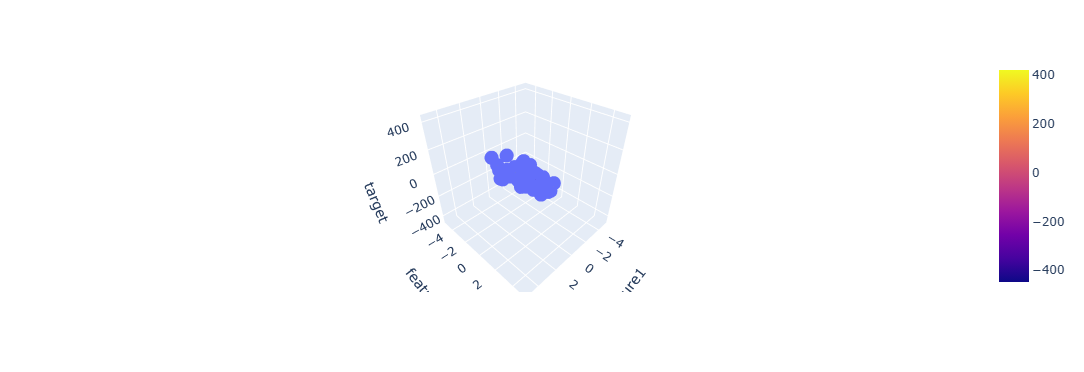

In [58]:
fig = px.scatter_3d(df, x='feature1',y='feature2',z='target')
fig.add_trace(go.Surface(x=x,y=y,z=z))
fig.show()

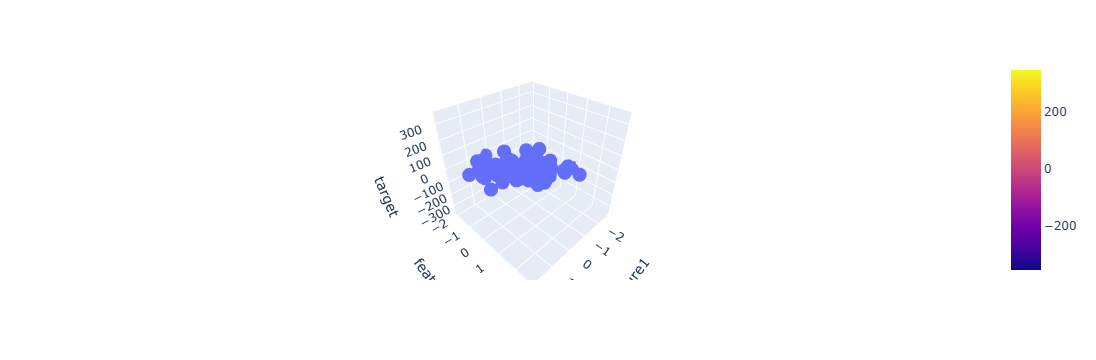

In [59]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go

# Generate data
X, y = make_regression(n_samples=100, n_features=2, n_informative=2,
                       n_targets=1, noise=50, random_state=42)
df = pd.DataFrame({'feature1': X[:, 0], 'feature2': X[:, 1], 'target': y})

# Train model
X_train, X_test, y_train, y_test = train_test_split(
    df[['feature1', 'feature2']], df['target'], test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)

# Create meshgrid for plane
x = np.linspace(df['feature1'].min(), df['feature1'].max(), 10)
y = np.linspace(df['feature2'].min(), df['feature2'].max(), 10)
xGrid, yGrid = np.meshgrid(x, y)

# Predict Z values
final = np.c_[xGrid.ravel(), yGrid.ravel()]  # shape (100, 2)
z = lr.predict(pd.DataFrame(final, columns=['feature1','feature2']))
z = z.reshape(xGrid.shape)  # shape (10,10)

# Plot
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.add_trace(go.Surface(x=xGrid, y=yGrid, z=z, opacity=0.5))  # use grid not 1D
fig.show()
